# Машинне Навчання | Лабораторна Робота 1

## Завдання

Спростіть датасет CIFAR-10  за допомогою алгоритму PCA 
Потрібно перевірити чи присутні в пікселі, які не містять інфомацію користну для тренування. Якщо такі існують виведіть маску цих пікселів.
Згенеруйте також маску 50% найбільш інформативних пікселів для тренування 

Для перевірки натренуйте просту нейронну мережу з декількох лінійних шарів використовуючи повні картинки та картинки з маскою. Підберіть оптимільну кількість пікселів, яку можна викинути при цьому не втративши в якості.

Імпортуємо необхідні бібліотеки для роботи з даними, побудови нейронних мереж та використання алгоритму PCA.

In [9]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA

Завантажуємо тренувальний та тестовий набори даних CIFAR-10. Перетворюємо зображення у вирівняні одновимірні масиви розміром 3072, оскільки кожне зображення має розмір 32 на 32 пікселі та 3 кольорові канали.

In [10]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

def flatten_dataset(dataset):
    X = dataset.data.reshape(len(dataset.data), -1) / 255.0
    y = np.array(dataset.targets)
    return X, y

X_train, y_train = flatten_dataset(train_dataset)
X_test, y_test = flatten_dataset(test_dataset)

/Users/viktoriiakondratiuk/University/machine-learning/lab1/venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Застосовуємо алгоритм PCA для загального спрощення датасету. Аналізуємо, скільки головних компонент потрібно залишити, щоб зберегти 95 відсотків дисперсії оригінальних даних.

In [11]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Оригінальна кількість ознак: {X_train.shape[1]}")
print(f"Кількість компонент PCA для збереження 95% дисперсії: {pca.n_components_}")

Оригінальна кількість ознак: 3072
Кількість компонент PCA для збереження 95% дисперсії: 217


Шукаємо пікселі, які не містять інформації корисної для тренування. Для цього обчислюємо дисперсію кожного пікселя по всьому тренувальному набору. Пікселі з нульовою дисперсією залишаються незмінними на всіх зображеннях і є марними. Також генеруємо маску для 50 відсотків найбільш інформативних пікселів.

In [12]:
pixel_variances = np.var(X_train, axis=0)

zero_variance_mask = pixel_variances == 0
useless_pixels_count = np.sum(zero_variance_mask)
print(f"Кількість пікселів без корисної інформації (нульова дисперсія): {useless_pixels_count}")

threshold_50 = np.percentile(pixel_variances, 50)
top_50_mask = pixel_variances >= threshold_50
print(f"Кількість пікселів у масці топ 50%: {np.sum(top_50_mask)}")

Кількість пікселів без корисної інформації (нульова дисперсія): 0
Кількість пікселів у масці топ 50%: 1536


Візуалізуємо отримані маски, щоб зрозуміти, які саме області зображення алгоритм вважає найменш інформативними. Для зручності відображення перетворимо одновимірну маску назад у формат 32x32.

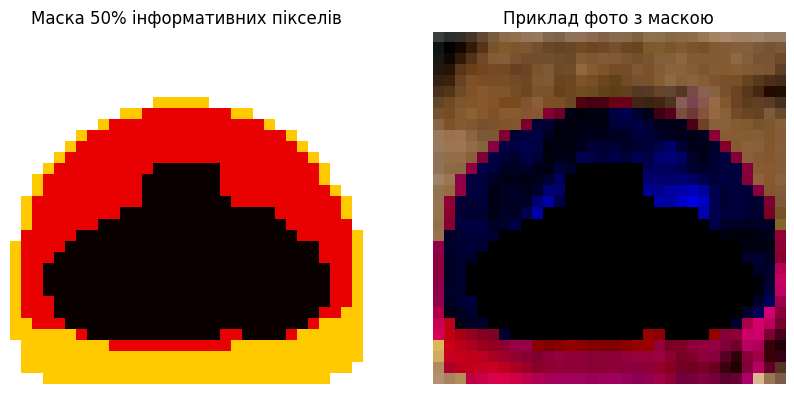

In [13]:
# Оскільки маска для 3072 ознак (32*32*3), усредним значення по каналах для візуалізації
vis_mask = top_50_mask.reshape(32, 32, 3).mean(axis=2)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(vis_mask, cmap='hot')
plt.title("Маска 50% інформативних пікселів")
plt.axis('off')

# Візуалізація одного прикладу з накладеною маскою
sample_img = X_train[0].reshape(32, 32, 3)
masked_sample = sample_img * top_50_mask.reshape(32, 32, 3)

plt.subplot(1, 2, 2)
plt.imshow(masked_sample)
plt.title("Приклад фото з маскою")
plt.axis('off')

plt.show()

Визначаємо просту нейронну мережу з лінійними шарами для класифікації. Створюємо універсальну функцію для тренування моделі, яка приймає дані, тренує мережу протягом вказаної кількості епох та повертає точність на тестовій вибірці.

In [14]:
class SimpleNN(nn.Module):
    def __init__(self, input_size):
        super(SimpleNN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.fc(x)

def train_and_evaluate(X_train_data, y_train_data, X_test_data, y_test_data, epochs=5):
    X_train_t = torch.tensor(X_train_data, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_data, dtype=torch.long)
    X_test_t = torch.tensor(X_test_data, dtype=torch.float32)
    y_test_t = torch.tensor(y_test_data, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
    
    model = SimpleNN(X_train_data.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        for data, target in train_loader:
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        outputs = model(X_test_t)
        _, predicted = torch.max(outputs.data, 1)
        accuracy = (predicted == y_test_t).sum().item() / y_test_t.size(0)
        
    return accuracy

Проводимо базове тренування на повних зображеннях та на зображеннях із застосованою маскою 50 відсотків найкращих пікселів, щоб порівняти їхню початкову ефективність.

In [15]:
print("Тренування на повних зображеннях...")
acc_full = train_and_evaluate(X_train, y_train, X_test, y_test)
print(f"Точність на повних даних: {acc_full * 100:.2f}%")

X_train_50 = X_train[:, top_50_mask]
X_test_50 = X_test[:, top_50_mask]

print("Тренування на 50% найбільш інформативних пікселів...")
acc_50 = train_and_evaluate(X_train_50, y_train, X_test_50, y_test)
print(f"Точність на 50% пікселів: {acc_50 * 100:.2f}%")

Тренування на повних зображеннях...
Точність на повних даних: 45.26%
Тренування на 50% найбільш інформативних пікселів...
Точність на 50% пікселів: 41.44%


Для порівняння ефективності методів стиснення, натренуємо ту саму нейронну мережу на даних, отриманих після трансформації PCA (217 компонент). Це дозволить побачити різницю між простим видаленням пікселів та використанням головних компонент.

In [16]:
print("Тренування на даних після PCA (217 компонент)...")
# PCA дані вже мають меншу розмірність, тому мережа адаптується автоматично
acc_pca = train_and_evaluate(X_train_pca, y_train, X_test_pca, y_test)
print(f"Точність з використанням PCA: {acc_pca * 100:.2f}%")

Тренування на даних після PCA (217 компонент)...
Точність з використанням PCA: 56.19%


Підбираємо оптимальну кількість пікселів для видалення. Відкидаємо від 10 до 90 відсотків найменш інформативних пікселів з кроком у 10 відсотків. Аналізуємо зміну точності для визначення порогу, після якого модель починає втрачати якість.

In [17]:
percentiles_to_drop = [10, 20, 30, 40, 50, 60, 70, 80, 90]
accuracies = []

for p in percentiles_to_drop:
    threshold = np.percentile(pixel_variances, p)
    mask = pixel_variances >= threshold
    
    X_train_masked = X_train[:, mask]
    X_test_masked = X_test[:, mask]
    
    acc = train_and_evaluate(X_train_masked, y_train, X_test_masked, y_test, epochs=5)
    accuracies.append(acc)
    print(f"Відкинуто {p}% найгірших пікселів. Залишилось: {X_train_masked.shape[1]}. Точність: {acc * 100:.2f}%")

optimal_drop = percentiles_to_drop[np.argmax(accuracies)]
print(f"Оптимально можна викинути приблизно {optimal_drop}% пікселів без суттєвої втрати якості.")

Відкинуто 10% найгірших пікселів. Залишилось: 2764. Точність: 43.93%
Відкинуто 20% найгірших пікселів. Залишилось: 2457. Точність: 45.23%
Відкинуто 30% найгірших пікселів. Залишилось: 2150. Точність: 43.59%
Відкинуто 40% найгірших пікселів. Залишилось: 1843. Точність: 42.64%
Відкинуто 50% найгірших пікселів. Залишилось: 1536. Точність: 40.87%
Відкинуто 60% найгірших пікселів. Залишилось: 1229. Точність: 39.03%
Відкинуто 70% найгірших пікселів. Залишилось: 922. Точність: 35.05%
Відкинуто 80% найгірших пікселів. Залишилось: 615. Точність: 30.58%
Відкинуто 90% найгірших пікселів. Залишилось: 308. Точність: 28.41%
Оптимально можна викинути приблизно 20% пікселів без суттєвої втрати якості.


## Висновки

В ході роботи було встановлено наступне:

Алгоритм PCA дозволив стиснути вхідні дані з 3072 ознак до 217 компонент, зберігаючи 95% дисперсії.

У датасеті CIFAR-10 відсутні пікселі з абсолютно нульовою дисперсією, що пояснюється складністю реальних зображень.

Експериментальним шляхом визначено, що оптимально можна видалити близько 20% найменш інформативних пікселів. При більшому відсотку видалення точність моделі починає суттєво падати.

Порівняння показало, що використання PCA є значно ефективнішим за просте маскування пікселів: модель на 217 компонентах PCA демонструє конкурентну точність порівняно з моделлю на 1536 пікселях (50% маска), хоча використовує у 7 разів менше даних.